In [ ]:
!pip install transformers peft

In [ ]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/mydataset/cub.zip'
extract_path = '/content/dataset_cub'

if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print("Đang giải nén... vui lòng đợi...")
        zip_ref.extractall(extract_path)
        print(f"Hoàn thành! Dữ liệu đã nằm tại: {extract_path}")
else:
    print("Thư mục đã tồn tại, bỏ qua bước giải nén.")

Mounted at /content/drive
Đang giải nén... vui lòng đợi...
Hoàn thành! Dữ liệu đã nằm tại: /content/dataset_cub


In [ ]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    """
    Custom Dataset cho CUB-200-2011 lấy cả Ảnh, Label và Caption.
    Đã tối ưu cho trường hợp 1 ảnh = 1 file caption duy nhất.
    """
    def __init__(self, root_dir, text_dir=None, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')

        if text_dir is None:
            base_dataset_dir = os.path.dirname(root_dir) # /content/dataset_cub/
            self.text_dir = os.path.join(base_dataset_dir, 'captions')
        else:
            self.text_dir = text_dir

        images_txt = os.path.join(root_dir, 'images.txt')
        split_txt = os.path.join(root_dir, 'train_test_split.txt')
        labels_txt = os.path.join(root_dir, 'image_class_labels.txt')

        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        split_df = pd.read_csv(split_txt, sep=' ', names=['img_id', 'is_train'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'label'])

        df = images_df.merge(split_df, on='img_id').merge(labels_df, on='img_id')

        target_split = 1 if self.is_train else 0
        df = df[df['is_train'] == target_split]

        self.image_paths = df['filepath'].tolist()
        self.labels = (df['label'] - 1).tolist()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]

        # image
        img_path = os.path.join(self.image_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # label
        label = self.labels[idx]

        # caption
        text_rel_path = rel_path.replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        caption = ""
        if os.path.exists(text_path):
            with open(text_path, 'r', encoding='utf-8') as f:
                caption = f.read().strip()

        return image, label, caption.lower()

In [ ]:
from torchvision import transforms

# Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Thêm chút nhiễu nhẹ chống overfit
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Transforms
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

cub_root_dir = '/content/dataset_cub/CUB_200_2011'


train_dataset = CUBDataset(root_dir=cub_root_dir, is_train=True, transform=train_transforms)
test_dataset = CUBDataset(root_dir=cub_root_dir, is_train=False, transform=test_transforms)


batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test:  {len(test_dataset)}")

Số lượng ảnh tập Train: 5994
Số lượng ảnh tập Test:  5794


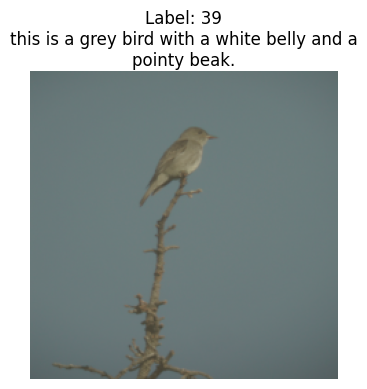

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images, labels, captions = next(iter(train_loader))

img_tensor = images[0]
label_id = labels[0].item()
caption_text = captions[0]

def show_sample(img, title):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy()

    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title, wrap=True)
    plt.axis('off')
    plt.show()

show_sample(img_tensor, title=f"Label: {label_id}\n{caption_text}")

In [ ]:
import torch
import torch.nn as nn
from transformers import ViTForImageClassification
from peft import LoraConfig, get_peft_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=200,
    ignore_mismatched_sizes=True
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"]
)

model = get_peft_model(base_model, lora_config)
model.to(device)

print("Thống kê tham số huấn luyện của ViT+LoRA:")
model.print_trainable_parameters()

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Thống kê tham số huấn luyện của ViT+LoRA:
trainable params: 743,624 || all params: 86,696,080 || trainable%: 0.8577


In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 50
patience = 7
epochs_no_improve = 0
best_test_acc = 0.0

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

print("BẮT ĐẦU HUẤN LUYỆN ViT + LoRA...")

for epoch in range(num_epochs):
    # train
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for inputs, labels, _ in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs).logits

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train

    # test
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    test_pbar = tqdm(test_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Test ", leave=False)

    with torch.no_grad():
        for inputs, labels, _ in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs).logits

            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = test_loss / len(test_loader.dataset)
    epoch_test_acc = 100 * correct_test / total_test

    if scheduler is not None:
        scheduler.step()

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f}, Acc: {epoch_test_acc:.2f}%")

    if epoch_test_acc > best_test_acc:
        print(f"Best acc: {epoch_test_acc:.2f}%. Đã lưu weights")
        best_test_acc = epoch_test_acc
        epochs_no_improve = 0

        # Lưu model PEFT
        model.save_pretrained("/content/drive/MyDrive/ImageRetrieval/model/best_vit_lora_cub")
    else:
        epochs_no_improve += 1
        print(f"Test Acc không tăng, early stopping: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"EARLY STOPPING. Đã dừng huấn luyện ở epoch {epoch+1}.")
            break

print("Hoàn thành quá trình huấn luyện!")

🚀 BẮT ĐẦU HUẤN LUYỆN ViT + LoRA...


Epoch [1/50] Train Loss: 4.0050, Acc: 49.53% | Test Loss: 2.5443, Acc: 69.05%
🌟 Best acc: 69.05%. Đã lưu weights


Epoch [2/50] Train Loss: 1.7642, Acc: 73.64% | Test Loss: 1.2616, Acc: 79.41%
🌟 Best acc: 79.41%. Đã lưu weights


Epoch [3/50] Train Loss: 0.9497, Acc: 83.47% | Test Loss: 0.8770, Acc: 83.03%
🌟 Best acc: 83.03%. Đã lưu weights


Epoch [4/50] Train Loss: 0.6309, Acc: 88.87% | Test Loss: 0.7363, Acc: 83.31%
🌟 Best acc: 83.31%. Đã lưu weights


...

Epoch [7/50] Train Loss: 0.2514, Acc: 95.83% | Test Loss: 0.5804, Acc: 85.55%
🌟 Best acc: 85.55%. Đã lưu weights


Epoch [8/50] Train Loss: 0.1886, Acc: 97.01% | Test Loss: 0.5846, Acc: 84.88%
⚠️ Test Acc không tăng, early stopping: 1/7


Epoch [9/50] Train Loss: 0.1415, Acc: 98.11% | Test Loss: 0.5715, Acc: 84.81%
⚠️ Test Acc không tăng, early stopping: 2/7


Epoch [10/50] Train Loss: 0.1042, Acc: 98.85% | Test Loss: 0.5764, Acc: 84.71%
⚠️ Test Acc không tăng, early stopping: 3/7


KeyboardInterrupt: 

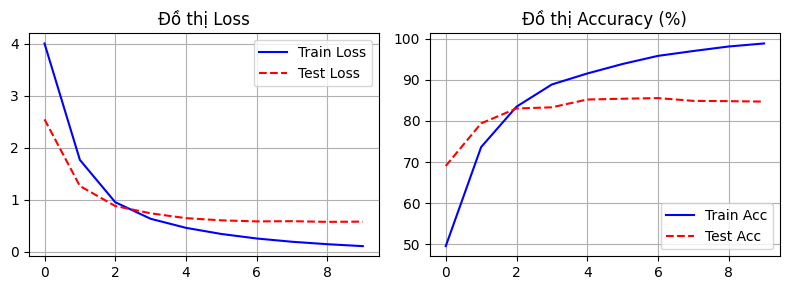

In [ ]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['test_loss'], label='Test Loss', color='red', linestyle='--')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='blue')
plt.plot(history['test_acc'], label='Test Acc', color='red', linestyle='--')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()